CNN есептері
1. Сверткіш қабат (Convolution Layer)
Есеп 1:

Тапсырма: Сверткіш операциясын қолданып feature map табыңыз.
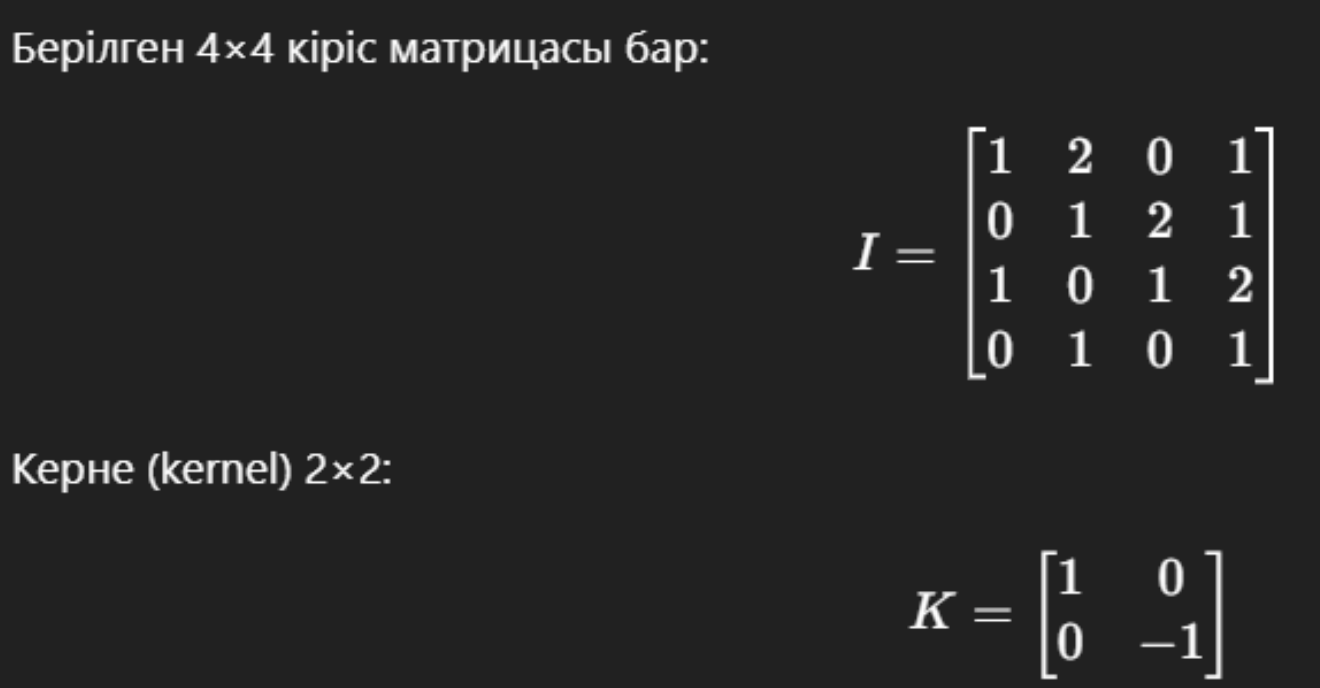

Python мысалын шығарыңыз және шығыс нәтижесін көрсетіңіз.


Шешімі:

Фильтрді матрицаның үстімен жылжытып, сәйкес элементтерді көбейтіп, қосамыз.

1-ші қадам:

(Сол жақ жоғарғы) (1⋅1)+(2⋅0)+(0⋅0)+(1⋅−1)=1+0+0−1=0

2-ші қадам:

(Бір қадам оңға) (2⋅1)+(0⋅0)+(1⋅0)+(2⋅−1)=2+0+0−2=0

... осылайша барлық 9 нүктені есептейміз.

In [1]:
import numpy as np
from scipy.signal import convolve2d

I = np.array([[1, 2, 0, 1], [0, 1, 2, 1], [1, 0, 1, 2], [0, 1, 0, 1]])
K = np.array([[1, 0], [0, -1]])

feature_map = convolve2d(I, K, mode='valid')
feature_map

array([[0, 0, 1],
       [0, 0, 0],
       [0, 0, 0]])

2. Активация функциясы

Есеп 2:

 Feature map нәтижесін ReLU функциясына салыңыз

Тапсырма: Сверткіш нәтижесін ReLU арқылы өңдеңіз.


Python-да массивпен есептеңіз.


In [2]:
def relu(x):
    return np.maximum(0, x)

In [3]:
relu_output = relu(feature_map)
relu_output

array([[0, 0, 1],
       [0, 0, 0],
       [0, 0, 0]])

3. Pooling

Есеп 3:

 Берілген feature map (4×4) бар:

Тапсырма: 2×2 Max Pooling қолданыңыз, stride = 2

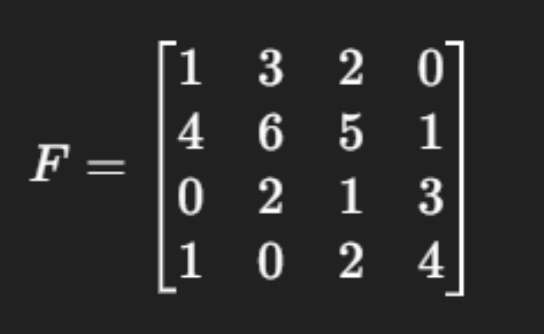

Нәтижені көрсетіңіз.


In [4]:
F = np.array([
    [1, 3, 2, 0],
    [4, 6, 5, 1],
    [0, 2, 1, 3],
    [1, 0, 2, 4]
])

In [7]:
def max_pooling(input_matrix, size=2, stride=2):
    # Шығыс матрицасының өлшемін есептеу
    h, w = input_matrix.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1

    pooled = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            # 2x2 терезені кесіп алу және максимумын табу [cite: 21]
            window = input_matrix[i*stride:i*stride+size, j*stride:j*stride+size]
            pooled[i, j] = np.max(window)

    return pooled

result_3 = max_pooling(F)
print("Max Pooling output (2x2, stride=2):")

result_3

Max Pooling output (2x2, stride=2):


array([[6., 5.],
       [2., 4.]])

4. Dropout

Есеп 4:

 Берілген feature map:

Тапсырма: Dropout қолдану (rate = 0.5)

F= [[2 0][3 1]]


Кездейсоқ mask генерациялап, жаңа feature map есептеңіз


In [8]:
F = np.array([[2, 0], [3, 1]])
rate = 0.5

mask = np.random.binomial(1, 1-rate, size=F.shape)

dropout_result = F * mask
dropout_result

array([[2, 0],
       [3, 0]])

5. Batch Normalization
Есеп 5:
 Берілген нейрон қабатының шығуы:

 X=[2,4,6,8]

Тапсырма: Batch Normalization қолданыңыз (ε=0.01)


Қадамдарды көрсетіп есептеңіз:




In [9]:
X = np.array([2, 4, 6, 8])
epsilon = 0.01


mu = np.mean(X)
var = np.var(X)

# x_hat = (x - mu) / sqrt(var + epsilon)
X_hat = (X - mu) / np.sqrt(var + epsilon)

print(f"Орташа мән (mu): {mu}")
print(f"Дисперсия (sigma^2): {var}")
print(f"Нормализацияланған мәндер (X_hat): {X_hat}")

Орташа мән (mu): 5.0
Дисперсия (sigma^2): 5.0
Нормализацияланған мәндер (X_hat): [-1.34030115 -0.44676705  0.44676705  1.34030115]


6. Трансферлік оқыту (Transfer Learning)

Есеп 6:

 Сізде CIFAR-10 деректер жинағы бар (10 классы бар).

Тапсырма: Алдын ала оқытылған ResNet50 моделін пайдаланып соңғы 10 класты классификациялайтын модель құрыңыз.


Python Keras коды мен model.summary() нәтижесін көрсетіңіз.


In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

7. Қосымша есеп (композит)

Есеп 7:

 Берілген сурет 28×28 пиксель.

3×3 керне қолдану, ReLU арқылы өткізу, Max Pooling 2×2 қолдану, Dropout rate=0.25.


Python кодын жасап, соңғы feature map өлшемін есептеңіз.


In [11]:
import tensorflow as tf

model = models.Sequential([
    # Input: 28x28 (мысалы, 1 каналды сұр түсті сурет)
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(filters=1, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25)
])

model.summary()

# Математикалық есептеуі:
# Conv (28-3+1) = 26x26
# MaxPool (26/2) = 13x13

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 1)      │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)